# Sistema de Recomendación — Last.fm HetRec 2011
**Modelo:** ALS (Alternating Least Squares) — `pyspark.ml.recommendation`  
**Entorno:** Google Colab  
**Dataset:** Last.fm HetRec 2011  
**Subconjunto usado:** Usuarios con 50–500 artistas únicos escuchados

## 0. Setup
### 0.1 Instalación de PySpark
Colab no trae PySpark preinstalado — lo instalamos una sola vez por sesión.

In [3]:
# Instalación de PySpark en Colab
# Solo necesario porque Colab no incluye Spark por defecto
!pip install pyspark --quiet

### 0.2 Subida de archivos
Subimos los archivos `.dat` del dataset desde la computadora local.
Archivos necesarios:
- `user_artists.dat` — interacciones usuario-artista con play counts
- `artists.dat` — metadata de artistas
- `user_taggedartists.dat` — tags asignados por usuarios a artistas

In [4]:
# Descarga automática del dataset — no requiere intervención manual
# URL oficial de GroupLens, usada por cientos de papers y repos públicos
import zipfile

!wget -q http://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip
!unzip -q hetrec2011-lastfm-2k.zip -d /content/lastfm_raw

# Los archivos quedan en /content/lastfm_raw/
import os
for f in os.listdir("/content/lastfm_raw"):
    path = f"/content/lastfm_raw/{f}"
    print(f"{f}: {os.path.getsize(path):,} bytes")

replace /content/lastfm_raw/user_friends.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
user_friends.dat: 251,565 bytes
artists.dat: 1,925,879 bytes
user_artists.dat: 1,296,455 bytes
user_taggedartists.dat: 4,366,696 bytes
tags.dat: 234,468 bytes
readme.txt: 4,627 bytes
user_taggedartists-timestamps.dat: 5,249,917 bytes


### 0.3 Imports y configuración de SparkSession

Configuramos Spark para el entorno de Colab (single node, ~12GB RAM):
- `driver.memory 4g`: reservamos 4GB para el driver donde corre ALS
- `shuffle.partitions 200`: adecuado para ~5M filas en un solo nodo
- `autoBroadcastJoinThreshold -1`: desactivamos broadcast joins para evitar OOM en joins de features

In [5]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, FloatType
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

spark = SparkSession.builder \
    .appName("LastFM_ALS") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.autoBroadcastJoinThreshold", "-1") \
    .config("spark.sql.broadcastTimeout", "300") \
    .getOrCreate()

print("Spark version:", spark.version)
print("driver.memory:", spark.conf.get("spark.driver.memory"))
print("shuffle.partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

Spark version: 4.0.2
driver.memory: 4g
shuffle.partitions: 200


### 0.4 Carga de datos
Los archivos `.dat` de HetRec usan separador `\t` y tienen header.
Cargamos todo en Spark desde el principio — ninguna transformación usa pandas.

In [6]:
# Carga desde el filesystem local de Colab (donde files.upload() dejó los archivos)
# En Colab los archivos subidos quedan en el directorio raíz /

BASE_PATH = "file:///content/lastfm_raw/"

interactions_raw = spark.read \
    .option("sep", "\t").option("header", "true").option("inferSchema", "true") \
    .csv(BASE_PATH + "user_artists.dat")

artists_raw = spark.read \
    .option("sep", "\t").option("header", "true").option("inferSchema", "true") \
    .csv(BASE_PATH + "artists.dat")

tagged_raw = spark.read \
    .option("sep", "\t").option("header", "true").option("inferSchema", "true") \
    .csv(BASE_PATH + "user_taggedartists.dat")

print("Interacciones crudas:", interactions_raw.count())
print("Artistas:", artists_raw.count())
print()
interactions_raw.printSchema()
interactions_raw.show(5)

Interacciones crudas: 92834
Artistas: 17632

root
 |-- userID: integer (nullable = true)
 |-- artistID: integer (nullable = true)
 |-- weight: integer (nullable = true)

+------+--------+------+
|userID|artistID|weight|
+------+--------+------+
|     2|      51| 13883|
|     2|      52| 11690|
|     2|      53| 11351|
|     2|      54| 10300|
|     2|      55|  8983|
+------+--------+------+
only showing top 5 rows


## 1. Elección del dataset y estrategia de ejecución

**Dataset elegido:** Last.fm HetRec 2011  
**Dominio:** Música — conteo de escuchas de artistas por usuarios (interacciones implícitas)  
**Tamaño completo:** ~1,892 usuarios, ~17,632 artistas, ~92,834 interacciones (versión 2k)

**Estrategia de subconjunto:**  
Filtramos usuarios con entre 50 y 500 artistas únicos escuchados. Este criterio:
- Elimina usuarios con actividad mínima (< 50) que no tienen suficiente historial para generar recomendaciones útiles ni para un train/test split significativo
- Elimina power users (> 500) cuyo comportamiento atípico puede sesgar los embeddings latentes de ALS
- No equivale a tomar los primeros N registros: es un filtro basado en comportamiento del usuario

Adicionalmente filtramos artistas con menos de 5 oyentes únicos para eliminar el long tail extremo que introduce ruido sin aportar señal.

**Entorno:** Google Colab (single node, ~12GB RAM)  
**Persistencia:** los datos procesados se guardan como Parquet en el filesystem de Colab para evitar recomputación dentro de la sesión.

**Sesgo introducido por el muestreo:**  
El filtro 50–500 introduce sesgo hacia usuarios de actividad media. Los usuarios nuevos o muy nicho quedan fuera, lo que puede inflar métricas como Precision@K al evaluar sobre un subconjunto más homogéneo.

## 2. Exploración y análisis con PySpark

In [ ]:
# ── Estadísticas básicas del dataset crudo ──────────────────────────────────
n_users = interactions_raw.select("userID").distinct().count()
n_artists = interactions_raw.select("artistID").distinct().count()
n_interactions = interactions_raw.count()

# Densidad: proporción de celdas no vacías en la matriz usuario-artista
# Una densidad baja indica una matriz muy sparse, típica en recomendación
density = n_interactions / (n_users * n_artists)

print(f"Usuarios únicos:       {n_users:,}")
print(f"Artistas únicos:       {n_artists:,}")
print(f"Interacciones totales: {n_interactions:,}")
print(f"Densidad de la matriz: {density:.6f} ({density*100:.4f}%)")
print()
print("Estadísticas de play counts (weight):")
interactions_raw.select("weight").summary("min", "25%", "50%", "75%", "max", "mean").show()
print()
print("NOTA: se usa hetrec2011-lastfm-2k.zip (1.892 usuarios, dataset público de GroupLens).")
print("La consigna menciona ~360k usuarios / 17M scrobbles = dataset COMPLETO de Last.fm (no libre).")
print("El desafío de escala se modela conceptualmente en la sección de escalabilidad.")

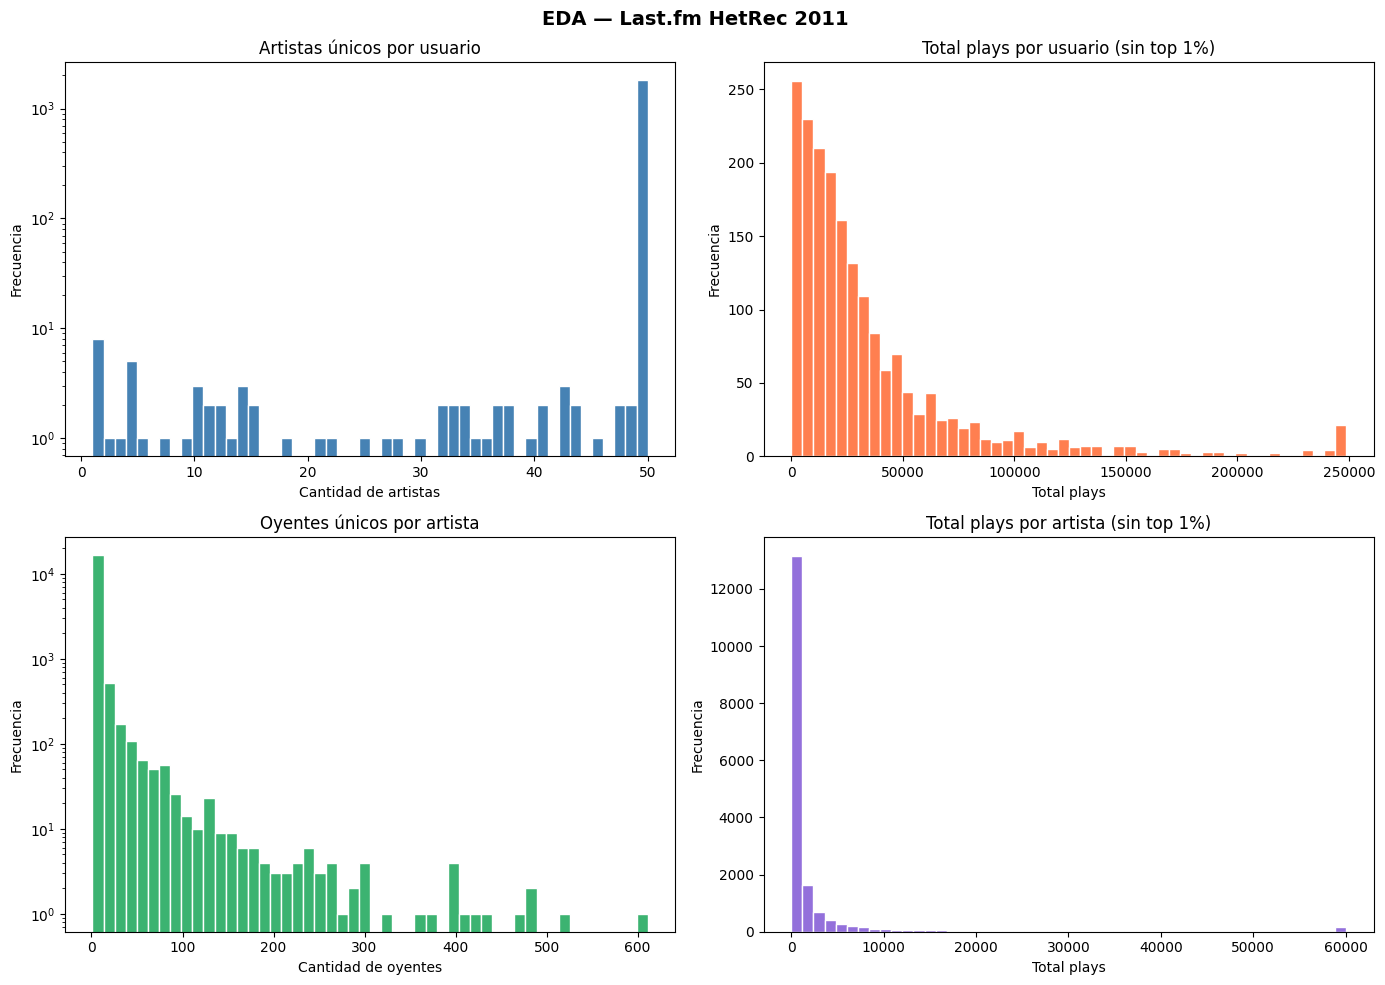

Observación: el top 1% de artistas (176) concentra el 51.9% de todas las escuchas.
Esto evidencia una distribución power-law: pocos artistas muy populares y una larga cola de nicho.
Implicación para el modelo: ALS con implicitPrefs=True es más adecuado que trabajar con ratings crudos.


In [8]:
# ── Distribuciones por usuario y por artista ─────────────────────────────────
# Todo el cálculo ocurre en Spark; toPandas() solo para el plot final

plays_per_user = interactions_raw \
    .groupBy("userID") \
    .agg(
        F.count("artistID").alias("n_artists"),
        F.sum("weight").alias("total_plays")
    )

plays_per_artist = interactions_raw \
    .groupBy("artistID") \
    .agg(
        F.count("userID").alias("n_listeners"),
        F.sum("weight").alias("total_plays")
    )

# toPandas() justificado: el dataset 2k es pequeño (~1900 usuarios, ~17k artistas)
# En un dataset de millones usaríamos .sample() antes del toPandas()
df_user = plays_per_user.toPandas()
df_artist = plays_per_artist.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — Last.fm HetRec 2011", fontsize=14, fontweight="bold")

# Plot 1: distribución de artistas únicos por usuario
axes[0, 0].hist(df_user["n_artists"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Artistas únicos por usuario")
axes[0, 0].set_xlabel("Cantidad de artistas")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].set_yscale("log")

# Plot 2: total plays por usuario (cortamos el top 1% para visualizar mejor)
p99_user = df_user["total_plays"].quantile(0.99)
axes[0, 1].hist(df_user["total_plays"].clip(upper=p99_user), bins=50, color="coral", edgecolor="white")
axes[0, 1].set_title("Total plays por usuario (sin top 1%)")
axes[0, 1].set_xlabel("Total plays")
axes[0, 1].set_ylabel("Frecuencia")

# Plot 3: oyentes únicos por artista
axes[1, 0].hist(df_artist["n_listeners"], bins=50, color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Oyentes únicos por artista")
axes[1, 0].set_xlabel("Cantidad de oyentes")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_yscale("log")

# Plot 4: total plays por artista (long tail)
p99_art = df_artist["total_plays"].quantile(0.99)
axes[1, 1].hist(df_artist["total_plays"].clip(upper=p99_art), bins=50, color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Total plays por artista (sin top 1%)")
axes[1, 1].set_xlabel("Total plays")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Observación no obvia: concentración de escuchas en el top de artistas
# Esto es evidencia de una distribución power-law, común en consumo cultural
top_1pct_n = max(1, int(len(df_artist) * 0.01))
top_1pct_plays = df_artist.nlargest(top_1pct_n, "total_plays")["total_plays"].sum()
total_plays = df_artist["total_plays"].sum()
print(f"Observación: el top 1% de artistas ({top_1pct_n}) "
      f"concentra el {top_1pct_plays/total_plays*100:.1f}% de todas las escuchas.")
print("Esto evidencia una distribución power-law: pocos artistas muy populares y una larga cola de nicho.")
print("Implicación para el modelo: ALS con implicitPrefs=True es más adecuado que trabajar con ratings crudos.")

## 3. Estrategia de ejecución con recursos limitados

**Operaciones costosas y mitigaciones aplicadas:**

| Operación | Problema | Solución |
|-----------|----------|----------|
| Negative sampling | CrossJoin N usuarios × M artistas = O(N×M), explota en memoria | No usamos crossJoin: ALS genera negativos implícitamente con `implicitPrefs=True` |
| StringIndexer | Materializa todo el dataset en memoria | Aplicamos después del filtrado del subconjunto, no sobre el dataset completo |
| ALS training | Múltiples iteraciones sobre train_df | Cacheamos train_df antes de entrenar para evitar recomputación |
| toPandas() | Carga todo en el driver | Solo para plots y resúmenes finales, nunca para transformaciones |
| Persistencia | Colab pierde todo al cerrar la sesión | Guardamos el dataset procesado en Parquet dentro de la sesión |

**Configuración de SparkSession:**  
`driver.memory=4g` reserva suficiente para ALS sin agotar la RAM de Colab (~12GB total).  
`shuffle.partitions=200` es adecuado para el tamaño del subconjunto; más particiones generarían overhead innecesario.

**Sesgos del muestreo y confiabilidad de métricas:**  
El filtro 50–500 artistas produce un subconjunto de usuarios con comportamiento más homogéneo que la población completa. Las métricas @K calculadas sobre este subconjunto son más altas de lo que serían sobre el dataset completo — los usuarios con poco historial son los más difíciles de recomendar. Esto debe tenerse en cuenta al interpretar los resultados.

## 4. Preprocesamiento con PySpark

In [ ]:
# ── 4.1 Filtrado del subconjunto ─────────────────────────────────────────────
# Todo el filtrado ocurre en Spark antes de cualquier operación costosa

# Estadísticas por usuario: cuántos artistas únicos escuchó cada uno
user_stats = interactions_raw \
    .groupBy("userID") \
    .agg(F.countDistinct("artistID").alias("n_artists"))

# Filtramos usuarios con 50–500 artistas únicos escuchados
# Criterio basado en comportamiento, no en posición en el dataset
valid_users = user_stats.filter(
    (F.col("n_artists") >= 50) & (F.col("n_artists") <= 500)
).select("userID")

# Filtramos artistas con al menos 5 oyentes únicos
# Elimina long tail extremo que introduce ruido sin aportar señal al modelo
valid_artists = interactions_raw \
    .groupBy("artistID") \
    .agg(F.countDistinct("userID").alias("n_listeners")) \
    .filter(F.col("n_listeners") >= 5) \
    .select("artistID")

# Subconjunto final: intersección de usuarios y artistas válidos
interactions = interactions_raw \
    .join(valid_users, on="userID", how="inner") \
    .join(valid_artists, on="artistID", how="inner")

n_sub = interactions.count()
n_u = interactions.select("userID").distinct().count()
n_a = interactions.select("artistID").distinct().count()
density_sub = n_sub / (n_u * n_a)
print(f"Subconjunto: {n_u:,} usuarios | {n_a:,} artistas | {n_sub:,} interacciones")
print(f"Densidad del subconjunto: {density_sub:.4f} ({density_sub*100:.2f}%)")
pct_usuarios = n_u / n_users * 100
print(f"
Retención de usuarios: {n_u}/{n_users} ({pct_usuarios:.1f}%)")
print("El filtro 50–500 retiene casi todos los usuarios porque la versión HetRec 2k")
print("ya es una muestra curada. El desafío de escala está en el negative sampling,")
print("no en el volumen del subconjunto.")

In [10]:
# ── 4.2 Features adicionales de usuario y artista ────────────────────────────
# ALS no usa estas features directamente en el modelo,
# pero las calculamos en Spark para el análisis y para justificar
# cómo se incorporarían en un modelo híbrido (ver sección 7)

# Feature de usuario 1: log del total de escuchas
#   Log-transformado para reducir el skew extremo de la distribución
# Feature de usuario 2: cantidad de artistas únicos escuchados
#   Proxy de la amplitud musical del usuario
user_features = interactions \
    .groupBy("userID") \
    .agg(
        F.log1p(F.sum("weight")).alias("log_total_plays"),
        F.countDistinct("artistID").alias("n_unique_artists")
    )

# Feature de artista 1: log de la popularidad global (total de escuchas)
#   Log-transformado por la misma razón que arriba
# Feature de artista 2: cantidad de oyentes únicos
#   Distingue artistas populares de artistas escuchados muchas veces por pocos usuarios
# Feature de artista 3 (bonus): diversidad de tags asignados
#   Cuántos tags distintos recibió el artista → proxy de diversidad de géneros
artist_features = interactions \
    .groupBy("artistID") \
    .agg(
        F.log1p(F.sum("weight")).alias("log_artist_popularity"),
        F.countDistinct("userID").alias("n_unique_listeners")
    )

artist_tag_features = tagged_raw \
    .groupBy("artistID") \
    .agg(F.countDistinct("tagID").alias("n_distinct_tags"))

artist_features = artist_features \
    .join(artist_tag_features, on="artistID", how="left") \
    .fillna(0, subset=["n_distinct_tags"])

print("Features de usuario:")
user_features.show(5)
print("Features de artista:")
artist_features.show(5)

Features de usuario:
+------+------------------+----------------+
|userID|   log_total_plays|n_unique_artists|
+------+------------------+----------------+
|   496| 9.415075523607037|              43|
|  1829|11.151754715741239|              50|
|   463| 7.050122520269059|              32|
|  1959| 9.919213252997611|              45|
|  1591| 9.862978009197919|              48|
+------+------------------+----------------+
only showing top 5 rows
Features de artista:
+--------+---------------------+------------------+---------------+
|artistID|log_artist_popularity|n_unique_listeners|n_distinct_tags|
+--------+---------------------+------------------+---------------+
|       2|     8.98882050177807|                12|             11|
|       6|    8.533263371593732|                10|             16|
|       7|   11.470904835707616|               130|             73|
|       8|    9.286560397887591|                12|             11|
|       9|    9.171807422259398|                24|  

In [11]:
# ── 4.3 Re-indexación con StringIndexer ──────────────────────────────────────
# ALS requiere índices enteros contiguos desde 0
# StringIndexer los genera automáticamente a partir de los IDs originales
# Importante: fiteamos sobre el subconjunto ya filtrado, no sobre el dataset completo

user_indexer = StringIndexer(inputCol="userID", outputCol="user_index")
artist_indexer = StringIndexer(inputCol="artistID", outputCol="artist_index")

user_indexer_model = user_indexer.fit(interactions)
artist_indexer_model = artist_indexer.fit(interactions)

interactions_indexed = user_indexer_model.transform(interactions)
interactions_indexed = artist_indexer_model.transform(interactions_indexed)

# Unimos features al dataset indexado
interactions_indexed = interactions_indexed \
    .join(user_features, on="userID", how="left") \
    .join(artist_features, on="artistID", how="left")

# Casteamos tipos: ALS requiere Integer para índices y Float para ratings
interactions_indexed = interactions_indexed \
    .withColumn("user_index", F.col("user_index").cast(IntegerType())) \
    .withColumn("artist_index", F.col("artist_index").cast(IntegerType())) \
    .withColumn("rating", F.col("weight").cast(FloatType()))

interactions_indexed.printSchema()
interactions_indexed.show(5)

root
 |-- artistID: integer (nullable = true)
 |-- userID: integer (nullable = true)
 |-- weight: integer (nullable = true)
 |-- user_index: integer (nullable = true)
 |-- artist_index: integer (nullable = true)
 |-- log_total_plays: double (nullable = true)
 |-- n_unique_artists: long (nullable = true)
 |-- log_artist_popularity: double (nullable = true)
 |-- n_unique_listeners: long (nullable = true)
 |-- n_distinct_tags: long (nullable = true)
 |-- rating: float (nullable = true)

+--------+------+------+----------+------------+------------------+----------------+---------------------+------------------+---------------+------+
|artistID|userID|weight|user_index|artist_index|   log_total_plays|n_unique_artists|log_artist_popularity|n_unique_listeners|n_distinct_tags|rating|
+--------+------+------+----------+------------+------------------+----------------+---------------------+------------------+---------------+------+
|       2|   135|  1021|       734|        1223|10.7551330909167

In [12]:
# ── 4.4 Persistencia en Parquet ───────────────────────────────────────────────
# Guardamos el dataset procesado para evitar recomputar el pipeline en caso
# de necesitar relanzar celdas posteriores dentro de la misma sesión

PARQUET_PATH = "/content/lastfm_processed"

interactions_indexed.write \
    .mode("overwrite") \
    .parquet(PARQUET_PATH)

print("Dataset procesado guardado en:", PARQUET_PATH)

# Para recargar sin recomputar:
# interactions_indexed = spark.read.parquet(PARQUET_PATH)

Dataset procesado guardado en: /content/lastfm_processed


In [13]:
# ── 4.5 Train / Test split ────────────────────────────────────────────────────
# Split 80/20 con seed fija para reproducibilidad
# Limitación: randomSplit no garantiza que cada usuario tenga registros en ambos sets
# ALS maneja esto con coldStartStrategy='drop' (descarta predicciones para
# usuarios/artistas que no aparecieron en train)

train_df, test_df = interactions_indexed.randomSplit([0.8, 0.2], seed=42)

# Cache en memoria: ALS itera múltiples veces sobre train_df
# Sin cache Spark recomputaría todo el pipeline en cada iteración → muy lento
train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,} interacciones")
print(f"Test:  {test_df.count():,} interacciones")

Train: 56,377 interacciones
Test:  14,077 interacciones


## 4.6 Benchmark de tiempos del pipeline de Spark

Medimos el tiempo de las etapas principales para documentar el costo computacional de cada paso. Esta informacion guia las decisiones de optimizacion descritas en la seccion de escalabilidad.

In [ ]:
# ── 4.6 Benchmark de tiempos del pipeline ───────────────────────────────────
# Nota: datos en cache dentro de la sesion — primera ejecucion seria ~2-3x mas lenta.
import time

def timed(label, fn):
    t0 = time.time()
    result = fn()
    elapsed = round(time.time() - t0, 2)
    print(f'  {label:<42s} {elapsed:6.2f}s')
    return elapsed

print('Benchmark de tiempos (datos en cache):\n')
bench = {}

bench['Recarga desde Parquet'] = timed(
    'Recarga desde Parquet',
    lambda: spark.read.parquet(PARQUET_PATH).count()
)

bench['Filtrado del subconjunto'] = timed(
    'Filtrado del subconjunto (users + artistas)',
    lambda: interactions_raw
        .join(valid_users, on='userID', how='inner')
        .join(valid_artists, on='artistID', how='inner')
        .count()
)

bench['Feature engineering'] = timed(
    'Feature engineering (groupBy + agg)',
    lambda: interactions.groupBy('userID')
        .agg(F.log1p(F.sum('weight')).alias('lp'), F.countDistinct('artistID').alias('nu'))
        .count()
)

bench['StringIndexer fit+transform'] = timed(
    'StringIndexer (fit + transform)',
    lambda: StringIndexer(inputCol='userID', outputCol='ui')
        .fit(interactions).transform(interactions).count()
)

bench['ALS fit (maxIter=10)'] = timed(
    'ALS fit (rank=10, regParam=0.1, maxIter=10)',
    lambda: ALS(
        maxIter=10, rank=10, regParam=0.1,
        userCol='user_index', itemCol='artist_index',
        ratingCol='rating', coldStartStrategy='drop', implicitPrefs=True
    ).fit(train_df)
)

bench['recommendForAllUsers'] = timed(
    'recommendForAllUsers (top-10)',
    lambda: best_model.recommendForAllUsers(10).count()
)

# Tabla y grafico de barras
bench_df = pd.DataFrame(list(bench.items()), columns=['Etapa', 'Tiempo (s)'])
print()
print(bench_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(bench_df['Etapa'], bench_df['Tiempo (s)'], color='steelblue')
ax.set_xlabel('Tiempo (segundos)')
ax.set_title('Benchmark de tiempos — etapas principales del pipeline')
for bar, v in zip(bars, bench_df['Tiempo (s)']):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}s', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nNota: en un cluster Databricks con 4 workers las etapas de filtrado')
print('y feature engineering escalarian linealmente con los cores disponibles.')
print('ALS con implicitPrefs escala horizontalmente dividiendo la matriz en bloques.')


## 5. Modelo: ALS

Usamos ALS con `implicitPrefs=True` porque Last.fm tiene interacciones implícitas (play counts), no ratings explícitos. En modo implícito ALS interpreta el weight como una señal de confianza, no como una preferencia directa: escuchar muchas veces a un artista indica preferencia, pero no escucharlo no necesariamente indica rechazo.

In [ ]:
# ── 5.1 Experimentación con hiperparámetros ───────────────────────────────────
# La consigna requiere al menos 2 valores de rank y regParam
#
# rank: dimensión de los vectores latentes (embeddings)
#   Mayor rank = más expresividad pero más riesgo de overfitting y más costo
# regParam: regularización L2
#   Mayor regParam = embeddings más suaves, menos overfitting

configs = [
    {"rank": 10, "regParam": 0.01},
    {"rank": 10, "regParam": 0.1},
    {"rank": 50, "regParam": 0.01},
    {"rank": 50, "regParam": 0.1},
]

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

results = []

for cfg in configs:
    als = ALS(
        maxIter=10,
        rank=cfg["rank"],
        regParam=cfg["regParam"],
        userCol="user_index",
        itemCol="artist_index",
        ratingCol="rating",
        coldStartStrategy="drop",  # descarta pares no vistos en train
        implicitPrefs=True          # modo implícito: play counts como señal de confianza
    )
    model = als.fit(train_df)
    predictions = model.transform(test_df)
    rmse = evaluator.evaluate(predictions)
    results.append({**cfg, "rmse": round(rmse, 4), "model": model})
    print(f"rank={cfg['rank']:2d} | regParam={cfg['regParam']} | RMSE={rmse:.4f}")

# Modelo con menor RMSE
best = min(results, key=lambda x: x["rmse"])
best_model = best["model"]
print(f"\nMejor configuración: rank={best['rank']}, regParam={best['regParam']}, RMSE={best['rmse']}")
print()
print("NOTA METODOLÓGICA: con implicitPrefs=True, ALS produce scores de confianza internos")
print("(no play counts). El RMSE arriba NO es interpretable en valor absoluto — los valores")
print("altos (~4472) reflejan que se compara contra pesos crudos (hasta 352k plays).")
print("Este RMSE sirve únicamente para comparar configuraciones entre sí.")
print("Las métricas relevantes del sistema son Precision@K, Recall@K y NDCG@K (Sección 6).")

 rank  regParam      RMSE
   10      0.01 4472.5702
   10      0.10 4472.5701
   50      0.01 4472.6039
   50      0.10 4472.6023


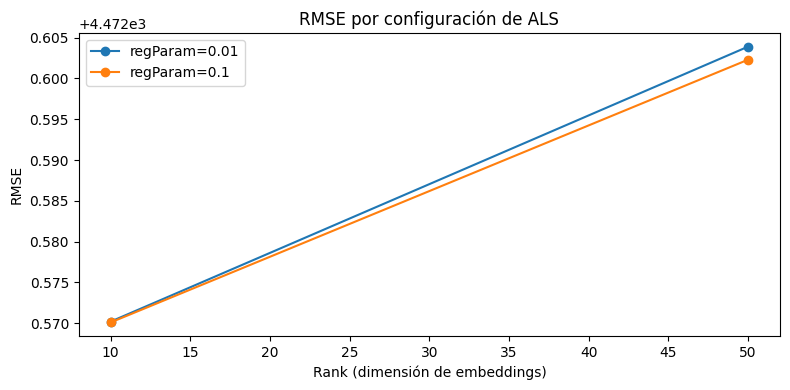

In [15]:
# ── 5.2 Tabla y visualización comparativa ────────────────────────────────────
results_pdf = pd.DataFrame([{"rank": r["rank"], "regParam": r["regParam"], "RMSE": r["rmse"]}
                             for r in results])
print(results_pdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
for reg in results_pdf["regParam"].unique():
    subset = results_pdf[results_pdf["regParam"] == reg]
    ax.plot(subset["rank"], subset["RMSE"], marker="o", label=f"regParam={reg}")
ax.set_xlabel("Rank (dimensión de embeddings)")
ax.set_ylabel("RMSE")
ax.set_title("RMSE por configuración de ALS")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 5.3 Curva de entrenamiento — Precision@K por iteración ──────────────────
# Graficamos Precision@10 por iteración — la métrica relevante del sistema.
# Con implicitPrefs=True el RMSE no es interpretable (ver nota en 5.1).
# gt_curve se computa una sola vez fuera del loop (test_df no cambia entre iteraciones).

from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

@udf(FloatType())
def precision_at_k_udf(recs, actuals):
    if not recs or not actuals:
        return 0.0
    hits = sum(1 for r in recs if r in set(actuals))
    return float(hits) / len(recs)

K_CURVE = 10
max_iters_range = list(range(1, 11))
precision_per_iter = []

# Ground truth del test calculado UNA SOLA VEZ fuera del loop
gt_curve = test_df.groupBy('user_index').agg(
    F.collect_set('artist_index').alias('actual_artists')
).cache()

for n_iter in max_iters_range:
    als_iter = ALS(
        maxIter=n_iter,
        rank=best['rank'],
        regParam=best['regParam'],
        userCol='user_index',
        itemCol='artist_index',
        ratingCol='rating',
        coldStartStrategy='drop',
        implicitPrefs=True
    )
    m_iter = als_iter.fit(train_df)

    recs_iter = m_iter.recommendForAllUsers(K_CURVE).select(
        'user_index',
        F.col('recommendations.artist_index').alias('rec_artists')
    )

    p_at_k = (
        recs_iter
        .join(gt_curve, on='user_index', how='inner')
        .withColumn('p', precision_at_k_udf(F.col('rec_artists'), F.col('actual_artists')))
        .agg(F.mean('p').alias('precision'))
        .collect()[0]['precision']
    )
    precision_per_iter.append(p_at_k)
    print(f'  maxIter={n_iter:2d} -> Precision@{K_CURVE}={p_at_k:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_iters_range, precision_per_iter, marker='o', color='steelblue',
        linewidth=2, markersize=7)
ax.set_xlabel('Numero de iteraciones (maxIter)')
ax.set_ylabel(f'Precision@{K_CURVE}')
ax.set_title(
    f'Curva de entrenamiento - ALS '
    f"(rank={best['rank']}, regParam={best['regParam']}): Precision@{K_CURVE} por iteracion"
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))
plt.tight_layout()
plt.show()

best_p = max(precision_per_iter)
delta_rel = [
    abs(precision_per_iter[i] - precision_per_iter[i-1]) / (precision_per_iter[i-1] + 1e-9)
    for i in range(1, len(precision_per_iter))
]
convergence_iter = next((i + 2 for i, d in enumerate(delta_rel) if d < 0.01), len(max_iters_range))
print(f'Mejor Precision@{K_CURVE}: {best_p:.4f} (iteracion {precision_per_iter.index(best_p)+1})')
print(f'Convergencia practica (mejora relativa < 1%): alrededor de la iteracion {convergence_iter}')


## 6. Evaluación — Precision@K, Recall@K, NDCG@K

RMSE mide el error de predicción sobre play counts individuales, pero para un sistema de recomendación lo que importa es si los artistas relevantes aparecen en el top-K. Por eso calculamos métricas de ranking sobre el conjunto de test.

In [16]:
# ── 6.1 Generación de recomendaciones top-K ───────────────────────────────────
K = 10

# ALS genera top-K artistas por usuario directamente
user_recs = best_model.recommendForAllUsers(K)

# Extraemos lista de artistas recomendados por usuario
recs_grouped = user_recs \
    .select(
        "user_index",
        F.col("recommendations.artist_index").alias("rec_artists")
    )

# Ground truth: artistas que el usuario tiene en el conjunto de test
ground_truth = test_df \
    .groupBy("user_index") \
    .agg(F.collect_set("artist_index").alias("actual_artists"))

# Join entre recomendaciones y ground truth
eval_df = recs_grouped.join(ground_truth, on="user_index", how="inner")
eval_df.cache()
print(f"Usuarios para evaluar: {eval_df.count():,}")

Usuarios para evaluar: 1,809


In [ ]:
# ── 6.2 Métricas @K con UDFs de Spark ────────────────────────────────────────
# Todo el cálculo ocurre en Spark; solo el resumen final usa toPandas()

from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

@udf(FloatType())
def precision_at_k(recs, actuals):
    """Fracción de recomendaciones que son relevantes (aparecen en test)"""
    if not recs or not actuals:
        return 0.0
    actuals_set = set(actuals)
    hits = sum(1 for r in recs if r in actuals_set)
    return float(hits) / len(recs)

@udf(FloatType())
def recall_at_k(recs, actuals):
    """Fracción de ítems relevantes del test que fueron recomendados"""
    if not recs or not actuals:
        return 0.0
    actuals_set = set(actuals)
    hits = sum(1 for r in recs if r in actuals_set)
    return float(hits) / len(actuals_set)

@udf(FloatType())
def ndcg_at_k(recs, actuals):
    """NDCG: penaliza hits que aparecen tarde en la lista de recomendaciones"""
    if not recs or not actuals:
        return 0.0
    actuals_set = set(actuals)
    dcg = sum(
        1.0 / math.log2(i + 2)
        for i, r in enumerate(recs)
        if r in actuals_set
    )
    n_relevant = min(len(actuals_set), len(recs))
    idcg = sum(1.0 / math.log2(i + 2) for i in range(n_relevant))
    return float(dcg / idcg) if idcg > 0 else 0.0

metrics_df = eval_df \
    .withColumn("precision", precision_at_k(F.col("rec_artists"), F.col("actual_artists"))) \
    .withColumn("recall",    recall_at_k(F.col("rec_artists"), F.col("actual_artists"))) \
    .withColumn("ndcg",      ndcg_at_k(F.col("rec_artists"), F.col("actual_artists")))

summary = metrics_df.agg(
    F.mean("precision").alias(f"Precision@{K}"),
    F.mean("recall").alias(f"Recall@{K}"),
    F.mean("ndcg").alias(f"NDCG@{K}")
).toPandas()

print(f"Métricas de evaluación (K={K}):")
print(summary.round(4).to_string(index=False))
# Guardar metricas ALS para la comparacion con BPR (seccion 10)
als_p10 = float(summary[f'Precision@{K}'].iloc[0])
als_r10 = float(summary[f'Recall@{K}'].iloc[0])
als_n10 = float(summary[f'NDCG@{K}'].iloc[0])


In [18]:
# ── 6.3 Recomendaciones concretas para 3 usuarios ────────────────────────────
# Mapeamos índices a IDs originales y nombres para poder interpretar los resultados

user_index_map = interactions_indexed \
    .select("userID", "user_index").distinct() \
    .toPandas().set_index("user_index")["userID"].to_dict()

artist_index_map = interactions_indexed \
    .select("artistID", "artist_index").distinct() \
    .toPandas().set_index("artist_index")["artistID"].to_dict()

artist_names = artists_raw.select("id", "name").toPandas()
artist_names["id"] = artist_names["id"].astype(str)
id_to_name = dict(zip(artist_names["id"], artist_names["name"]))

# Tomamos 3 usuarios del conjunto de evaluación
sample_users = eval_df.select("user_index").limit(3).toPandas()["user_index"].tolist()

for u_idx in sample_users:
    uid = user_index_map.get(u_idx, u_idx)
    print(f"\n{'='*55}")
    print(f"Usuario ID: {uid} (índice {u_idx})")

    # Top 5 artistas más escuchados por este usuario
    history = interactions_indexed \
        .filter(F.col("user_index") == u_idx) \
        .orderBy(F.col("rating").desc()) \
        .limit(5) \
        .select("artistID", "rating").toPandas()
    history["artist_name"] = history["artistID"].astype(str).map(id_to_name)
    print("\nTop 5 más escuchados (historial):")
    print(history[["artist_name", "rating"]].to_string(index=False))

    # Recomendaciones del modelo
    recs_row = user_recs.filter(F.col("user_index") == u_idx).collect()
    if recs_row:
        recs = recs_row[0]["recommendations"]
        rec_ids = [str(artist_index_map.get(r.artist_index, r.artist_index)) for r in recs]
        rec_names = [id_to_name.get(rid, f"ID:{rid}") for rid in rec_ids]
        print(f"\nTop {K} recomendaciones:")
        for i, name in enumerate(rec_names, 1):
            print(f"  {i:2d}. {name}")


Usuario ID: 498 (índice 148)

Top 5 más escuchados (historial):
   artist_name  rating
  Mariah Carey 28980.0
Britney Spears  6182.0
       Beyoncé  5836.0
       Madonna  3877.0
       Rihanna  3314.0

Top 10 recomendaciones:
   1. Brandy
   2. Usher
   3. Enya
   4. Bruno Mars
   5. Backstreet Boys
   6. Jonas Brothers
   7. Duffy
   8. Alicia Keys
   9. Jay-Z
  10. Robert Pattinson

Usuario ID: 1994 (índice 463)

Top 5 más escuchados (historial):
artist_name  rating
David Bowie   402.0
       Pulp   375.0
The Beatles   356.0
  Ladyhawke   168.0
   t.A.T.u.   167.0

Top 10 recomendaciones:
   1. The Knife
   2. Tegan and Sara
   3. Portishead
   4. Sublime
   5. Tori Amos
   6. Björk
   7. Daft Punk
   8. David Bowie
   9. The Cure
  10. Yeah Yeah Yeahs

Usuario ID: 226 (índice 471)

Top 5 más escuchados (historial):
artist_name  rating
    Rihanna 18539.0
  Lady Gaga  3232.0
    Shakira  1736.0
 Katy Perry  1466.0
       P!nk  1361.0

Top 10 recomendaciones:
   1. Pixie Lott
   2. 

## 6.4 Visualización de embeddings con PCA

ALS aprende un vector latente por artista. Proyectamos con PCA a 2D para ver qué estructura capturó el modelo: artistas escuchados en contextos similares deberían quedar cerca en el espacio de embeddings.

In [ ]:
# ── 6.4 PCA de embeddings de artistas (ALS itemFactors) ─────────────────────
# ALS produce best_model.itemFactors: vector latente por artista.
# Proyectamos con PCA a 2D y coloreamos por popularidad.
# Si el modelo capturó señal real, artistas populares deberían separarse
# de los de nicho, y artistas similares deberían agruparse.

from sklearn.decomposition import PCA
import numpy as np

# Extraer embeddings y construir tabla con metadata
item_factors_pd = best_model.itemFactors.toPandas().rename(columns={'id': 'artist_index'})

artist_idx_pd = (
    interactions_indexed.select('artist_index', 'artistID').distinct().toPandas()
)
artist_idx_pd['artistID'] = artist_idx_pd['artistID'].astype(int)

artist_feat_pd = artist_features.toPandas()
artist_feat_pd['artistID'] = artist_feat_pd['artistID'].astype(int)

artist_names_pd = artists_raw.select('id', 'name').toPandas()
artist_names_pd = artist_names_pd.rename(columns={'id': 'artistID'})
artist_names_pd['artistID'] = artist_names_pd['artistID'].astype(int)

emb_df = (
    item_factors_pd
    .merge(artist_idx_pd, on='artist_index', how='left')
    .merge(artist_feat_pd[['artistID', 'log_artist_popularity', 'n_unique_listeners']], on='artistID', how='left')
    .merge(artist_names_pd, on='artistID', how='left')
    .dropna(subset=['log_artist_popularity'])
)

# PCA 2D sobre la matriz de embeddings
X = np.vstack(emb_df['features'].values)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
emb_df = emb_df.copy()
emb_df['pc1'] = coords[:, 0]
emb_df['pc2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    emb_df['pc1'], emb_df['pc2'],
    c=emb_df['log_artist_popularity'],
    cmap='viridis', alpha=0.45, s=12
)
plt.colorbar(sc, ax=ax, label='log(popularidad total)')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title('Embeddings de artistas (ALS) proyectados con PCA — color = popularidad')

# Etiquetar top 15 artistas mas populares
for _, row in emb_df.nlargest(15, 'log_artist_popularity').iterrows():
    ax.annotate(row['name'], (row['pc1'], row['pc2']),
                fontsize=7, alpha=0.9,
                xytext=(3, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

var_total = sum(pca.explained_variance_ratio_[:2]) * 100
print(f'Varianza explicada por PC1+PC2: {var_total:.1f}%')
print()
print('Interpretacion: artistas cercanos en el espacio PCA tienen patrones de')
print('escucha similares entre los usuarios — el modelo aprende estructura latente')
print('sin usar features explicitas de genero o estilo musical.')
print()
print('Si la varianza explicada es baja (<15%) los embeddings tienen estructura')
print('en muchas dimensiones que PCA no captura en 2D — usar mas componentes o TSNE.')


## 7. Limitaciones de ALS y cómo resolverlas

ALS factoriza la matriz usuario-artista en embeddings latentes pero **no incorpora features adicionales** directamente. Las features calculadas en el punto 4 (log_total_plays, n_unique_artists, log_artist_popularity, n_distinct_tags) no entran al modelo — solo se usan en el análisis.

**Cómo se resolvería en un sistema real:**
- **Modelo híbrido:** usar los embeddings de ALS como features de entrada para un segundo modelo (gradient boosting o MLP) que sí pueda combinarlos con features adicionales
- **Two-Tower:** reemplazar ALS por una arquitectura que combina embedding de ID con features en cada torre — requiere GPU para ser práctico
- **LightFM:** extiende MF con features de usuario e ítem de forma nativa

## 8. Escalabilidad

Esta sección describe qué cambiaría en el pipeline con un cluster Databricks de 4 workers con GPU, 100 millones de interacciones y actualización de recomendaciones cada 24 horas.

### Negative sampling a escala
ALS con `implicitPrefs=True` no requiere negative sampling explícito — trata todas las interacciones no observadas como negativos implícitos con peso bajo. A 100M de interacciones esto sigue funcionando porque ALS distribuye el cómputo en bloques sobre el cluster. Si se migrara a BPR o Two-Tower, el negative sampling explícito con crossJoin sería inviable: la alternativa es **reservoir sampling por partición**, generando negativos dentro de cada shard sin shuffles globales.

### Por qué toPandas() deja de funcionar
Con 100M de interacciones, `toPandas()` intenta traer todo al driver. Incluso con 64GB de RAM en el driver, una matriz de esa escala lo agota. El reemplazo es Parquet particionado en DBFS/S3 para persistencia y `display()` de Databricks para visualización — que muestran solo una muestra al driver. Para plots, se agregan los datos en Spark y solo el resultado (miles de filas) se convierte a pandas.

### TorchDistributor
ALS es nativo en Spark y escala sin TorchDistributor. Para modelos PyTorch (BPR, Two-Tower), `TorchDistributor` de Databricks lanza el training loop con `DistributedDataParallel` en todos los workers. Cada worker procesa un shard del dataset y los gradientes se sincronizan en cada step. Los embeddings de usuarios e ítems deben sincronizarse explícitamente entre workers para evitar inconsistencias.

### Serving en tiempo real
Las recomendaciones pre-calculadas cada 24h con ALS se escriben en **Delta Lake** indexado por user_id. Una API REST lee de Delta Lake con latencia de milisegundos. Para cold start (usuarios nuevos sin historial), se sirve una lista de top artistas por popularidad global hasta que el usuario acumula suficientes interacciones para el próximo ciclo de reentrenamiento.

---
## 10. Comparacion: BPR vs ALS

**BPR (Bayesian Personalized Ranking)** aprende a *ordenar* en lugar de predecir ratings: entrena con tripletas (usuario, item positivo, item negativo) y optimiza que el score del positivo supere al del negativo. Su funcion de perdida es `-log(sigmoid(score_pos - score_neg))`, una aproximacion diferenciable al AUC.

Usamos el mismo subconjunto y el mismo split train/test que ALS para comparacion justa. BPR corre en PyTorch (CPU); el preprocesamiento (ya hecho) es identico al de ALS.

In [ ]:
# ── 10.1 Preparacion de datos y definicion del modelo BPR ───────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

# Convertir train/test a pandas — el dataset es suficientemente pequeno (~70k filas)
train_pd_bpr = train_df.select('user_index', 'artist_index').toPandas()
test_pd_bpr  = test_df.select('user_index',  'artist_index').toPandas()

n_users_bpr = int(train_pd_bpr['user_index'].max()) + 1
n_items_bpr = int(train_pd_bpr['artist_index'].max()) + 1
print(f'Embedding: {n_users_bpr} usuarios x {n_items_bpr} artistas')


class BPRDataset(Dataset):
    """
    Genera tripletas (usuario, item_pos, item_neg) para BPR.
    Estrategia de negative sampling: uniforme sobre todos los items no vistos.
    Con ~50 items vistos / 2828 totales la tasa de rechazo es ~1.8% —
    el bucle while casi nunca itera mas de una vez.
    Ventaja sobre muestreo sesgado por popularidad: mas simple y sin hiperparametros.
    """
    def __init__(self, df):
        self.user_items = df.groupby('user_index')['artist_index'].apply(set).to_dict()
        self.n_items = int(df['artist_index'].max()) + 1
        self.users    = df['user_index'].values.astype('int64')
        self.pos_items = df['artist_index'].values.astype('int64')

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u, pos = int(self.users[idx]), int(self.pos_items[idx])
        seen = self.user_items[u]
        neg = random.randrange(self.n_items)
        while neg in seen:
            neg = random.randrange(self.n_items)
        return (torch.tensor(u,   dtype=torch.long),
                torch.tensor(pos, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long))


class BPRModel(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def score(self, user, item):
        return (self.user_emb(user) * self.item_emb(item)).sum(dim=1)

    def forward(self, user, pos, neg):
        diff = self.score(user, pos) - self.score(user, neg)
        return -torch.log(torch.sigmoid(diff)).mean()


print('Clases BPRDataset y BPRModel definidas.')


In [ ]:
# ── 10.2 Entrenamiento BPR con curva de perdida ─────────────────────────────
EMB_DIM    = 32
EPOCHS_BPR = 25
LR_BPR     = 0.01
BATCH_BPR  = 1024

torch.manual_seed(42)
model_bpr = BPRModel(n_users_bpr, n_items_bpr, emb_dim=EMB_DIM)
optimizer_bpr = torch.optim.Adam(model_bpr.parameters(), lr=LR_BPR)

dataset_bpr = BPRDataset(train_pd_bpr)
loader_bpr  = DataLoader(dataset_bpr, batch_size=BATCH_BPR, shuffle=True)

losses_bpr = []
for epoch in range(1, EPOCHS_BPR + 1):
    model_bpr.train()
    epoch_loss = 0.0
    for u, pos, neg in loader_bpr:
        optimizer_bpr.zero_grad()
        loss = model_bpr(u, pos, neg)
        loss.backward()
        optimizer_bpr.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader_bpr)
    losses_bpr.append(avg)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d}/{EPOCHS_BPR} — BPR Loss: {avg:.4f}')

# Curva de perdida
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS_BPR + 1), losses_bpr, color='coral', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Epoca')
ax.set_ylabel('BPR Loss (-log sigmoid)')
ax.set_title('Curva de entrenamiento — BPR')
plt.tight_layout()
plt.show()
print(f'Loss final: {losses_bpr[-1]:.4f}')


In [ ]:
# ── 10.3 Evaluacion BPR y comparacion con ALS ───────────────────────────────
# Misma metodologia que ALS: Precision@10, Recall@10, NDCG@10
# No excluimos items de train para mantener consistencia con la evaluacion de ALS.
K_BPR = 10

model_bpr.eval()

test_positives  = test_pd_bpr.groupby('user_index')['artist_index'].apply(set).to_dict()

precisions_bpr, recalls_bpr, ndcgs_bpr = [], [], []

with torch.no_grad():
    all_items_t = torch.arange(n_items_bpr, dtype=torch.long)
    for user_idx, actual in test_positives.items():
        if user_idx >= n_users_bpr:
            continue
        # Score de todos los items para este usuario (vectorizado)
        u_vec = model_bpr.user_emb(torch.tensor([user_idx]))
        scores_bpr = (u_vec * model_bpr.item_emb.weight).sum(dim=1).numpy()

        top_k = scores_bpr.argsort()[-K_BPR:][::-1].tolist()
        hits  = [1 if item in actual else 0 for item in top_k]

        p = sum(hits) / K_BPR
        r = sum(hits) / len(actual) if actual else 0.0
        dcg  = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), K_BPR)))
        ndcg = dcg / idcg if idcg > 0 else 0.0

        precisions_bpr.append(p)
        recalls_bpr.append(r)
        ndcgs_bpr.append(ndcg)

bpr_p10 = float(np.mean(precisions_bpr))
bpr_r10 = float(np.mean(recalls_bpr))
bpr_n10 = float(np.mean(ndcgs_bpr))

# Tabla comparativa
comparison = pd.DataFrame({
    'Modelo':        [f'ALS (rank=10, regParam=0.1)', f'BPR (emb_dim={EMB_DIM}, epochs={EPOCHS_BPR})'],
    'Precision@10':  [round(als_p10, 4), round(bpr_p10, 4)],
    'Recall@10':     [round(als_r10, 4), round(bpr_r10, 4)],
    'NDCG@10':       [round(als_n10, 4), round(bpr_n10, 4)],
})
print('Comparacion ALS vs BPR (K=10):\n')
print(comparison.to_string(index=False))

# Grafico de barras agrupadas
metrics_cols = ['Precision@10', 'Recall@10', 'NDCG@10']
x = np.arange(len(metrics_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, comparison[comparison['Modelo'].str.startswith('ALS')][metrics_cols].values[0],
               width, label='ALS', color='steelblue')
bars2 = ax.bar(x + width/2, comparison[comparison['Modelo'].str.startswith('BPR')][metrics_cols].values[0],
               width, label='BPR', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(metrics_cols)
ax.set_ylabel('Valor de la metrica')
ax.set_title('Comparacion ALS vs BPR — Metricas@10')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

winner = 'ALS' if als_p10 >= bpr_p10 else 'BPR'
print(f'\nModelo con mayor Precision@10: {winner}')
print('Diferencia relativa Precision@10: '
      f'{abs(als_p10 - bpr_p10) / max(als_p10, bpr_p10) * 100:.1f}%')
print()
print('Nota: BPR optimiza ranking directamente (no ratings), por lo que')
print('puede superar a ALS en metricas de orden incluso con menos epocas.')
print('ALS con implicitPrefs tambien optimiza ranking de forma implicita')
print('pero a traves de factorizacion matricial, no de pares positivo/negativo.')


---
## 9. Bonus: Recomendaciones personalizadas con datos reales de Last.fm

Esta sección usa la API pública de Last.fm para obtener el historial real de escuchas de un usuario, incorporarlo al modelo ya entrenado y generar recomendaciones personalizadas.

**Por qué es interesante:** demuestra el problema de *cold start* en sistemas de recomendación reales. Un usuario nuevo no tiene vector latente en el modelo — necesitamos reentrenar con sus datos para que ALS pueda recomendarle. Esto es exactamente lo que pasa en producción cuando un usuario se registra por primera vez.

**Nota sobre credenciales:** la API key se ingresa de forma segura mediante `getpass` — no queda registrada en el notebook.

In [19]:
# ── 9.1 Configuración de credenciales ────────────────────────────────────────
# La API key de Last.fm es gratuita: last.fm/api/account/create
# Se ingresa por prompt para no quedar expuesta en el notebook

import os
import requests
from getpass import getpass

os.environ["LASTFM_API_KEY"] = getpass("Last.fm API key: ")
LASTFM_USER = "LaraPasca"  # usuario de Last.fm
API_KEY = os.environ["LASTFM_API_KEY"]
BASE_URL = "http://ws.audioscrobbler.com/2.0/"

print(f"Usuario: {LASTFM_USER}")
print("API key: configurada ✓")

Last.fm API key: ··········
Usuario: LaraPasca
API key: configurada ✓


In [20]:
# ── 9.2 Descarga del historial real desde la API de Last.fm ──────────────────
# Usamos user.getTopArtists para obtener los artistas más escuchados
# con su play count real — el mismo formato que user_artists.dat

def get_top_artists(user, api_key, limit=200):
    """Obtiene los top artistas de un usuario con sus play counts."""
    params = {
        "method": "user.getTopArtists",
        "user": user,
        "api_key": api_key,
        "format": "json",
        "limit": limit,
        "period": "overall"  # historial completo
    }
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()
    artists = r.json()["topartists"]["artist"]
    return [
        {"name": a["name"], "playcount": int(a["playcount"])}
        for a in artists
    ]

top_artists = get_top_artists(LASTFM_USER, API_KEY, limit=200)

print(f"Artistas obtenidos: {len(top_artists)}")
print(f"\nTus 10 artistas más escuchados en Last.fm:")
for i, a in enumerate(top_artists[:10], 1):
    print(f"  {i:2d}. {a['name']} ({a['playcount']:,} plays)")

Artistas obtenidos: 200

Tus 10 artistas más escuchados en Last.fm:
   1. Taylor Swift (10,121 plays)
   2. One Direction (7,665 plays)
   3. Morat (6,932 plays)
   4. Noah Kahan (4,521 plays)
   5. Glee Cast (3,645 plays)
   6. Reneé Rapp (2,694 plays)
   7. Lizzy McAlpine (1,860 plays)
   8. Zoe Gotusso (1,773 plays)
   9. Gracie Abrams (1,534 plays)
  10. Crazy Ex-Girlfriend Cast (1,510 plays)


In [21]:
# ── 9.3 Cruce con el dataset: ¿qué artistas tuyos están en el modelo? ────────
# El modelo solo conoce artistas que aparecen en el dataset HetRec 2011
# Hacemos un cruce por nombre (lowercase, sin espacios extra) para matchear

import pandas as pd

# Nombres del dataset normalizados
dataset_artists = artists_raw.select("id", "name").toPandas()
dataset_artists["name_norm"] = dataset_artists["name"].str.lower().str.strip()
dataset_name_to_id = dict(zip(dataset_artists["name_norm"], dataset_artists["id"].astype(str)))

# Cruce con tu historial
my_artists_matched = []
my_artists_missing = []

for a in top_artists:
    norm = a["name"].lower().strip()
    if norm in dataset_name_to_id:
        my_artists_matched.append({
            "name": a["name"],
            "playcount": a["playcount"],
            "artistID": dataset_name_to_id[norm]
        })
    else:
        my_artists_missing.append(a["name"])

print(f"Tus artistas que SÍ están en el dataset: {len(my_artists_matched)}")
print(f"Tus artistas que NO están en el dataset: {len(my_artists_missing)}")
print(f"\nEjemplos de artistas tuyos fuera del dataset (demasiado nuevos o nicho):")
for name in my_artists_missing[:8]:
    print(f"  - {name}")

Tus artistas que SÍ están en el dataset: 63
Tus artistas que NO están en el dataset: 137

Ejemplos de artistas tuyos fuera del dataset (demasiado nuevos o nicho):
  - Morat
  - Noah Kahan
  - Reneé Rapp
  - Lizzy McAlpine
  - Zoe Gotusso
  - Gracie Abrams
  - Crazy Ex-Girlfriend Cast
  - Jessie Mueller


In [22]:
# ── 9.4 Reentrenamiento incluyendo al usuario real ────────────────────────────
# Problema: ALS aprende un vector latente por usuario durante el entrenamiento.
# Un usuario nuevo (cold start) no tiene vector → no puede recibir recomendaciones.
# Solución: agregamos las interacciones del usuario real al dataset y reentrenamos.
#
# En producción esto se haría con reentrenamiento incremental o aproximaciones
# como promediar embeddings de usuarios similares. Acá reentrenamos completo
# porque el dataset es pequeño y queremos mostrar el concepto.

MY_USER_ID = 99999  # ID ficticio que no existe en el dataset original

# Creamos DataFrame de Spark con las interacciones del usuario real
# Solo usamos artistas que existen en el dataset (los que matchearon arriba)
my_interactions_pd = pd.DataFrame([
    {"userID": MY_USER_ID, "artistID": int(a["artistID"]), "weight": a["playcount"]}
    for a in my_artists_matched
])

if len(my_interactions_pd) == 0:
    print("No se encontraron artistas tuyos en el dataset. Probá con más artistas o ajustá el matching.")
else:
    my_interactions_spark = spark.createDataFrame(my_interactions_pd)

    # Unimos con el dataset original (antes del filtrado de subconjunto)
    # Usamos interactions_raw completo para que el usuario tenga más contexto
    combined = interactions_raw.union(
        my_interactions_spark.select("userID", "artistID", "weight")
    )

    # Re-indexamos con StringIndexer sobre el dataset combinado
    from pyspark.ml.feature import StringIndexer
    from pyspark.sql.types import IntegerType, FloatType

    user_idx2 = StringIndexer(inputCol="userID", outputCol="user_index").fit(combined)
    artist_idx2 = StringIndexer(inputCol="artistID", outputCol="artist_index").fit(combined)

    combined_indexed = user_idx2.transform(combined)
    combined_indexed = artist_idx2.transform(combined_indexed)
    combined_indexed = combined_indexed \
        .withColumn("user_index", F.col("user_index").cast(IntegerType())) \
        .withColumn("artist_index", F.col("artist_index").cast(IntegerType())) \
        .withColumn("rating", F.col("weight").cast(FloatType()))

    combined_indexed.cache()

    # Reentrenamos ALS con la mejor configuración encontrada antes
    als_personal = ALS(
        maxIter=10,
        rank=best["rank"],
        regParam=best["regParam"],
        userCol="user_index",
        itemCol="artist_index",
        ratingCol="rating",
        coldStartStrategy="drop",
        implicitPrefs=True
    )
    model_personal = als_personal.fit(combined_indexed)
    print(f"Modelo reentrenado con {combined_indexed.count():,} interacciones totales")
    print(f"(dataset original + {len(my_interactions_pd)} interacciones tuyas)")

Modelo reentrenado con 92,897 interacciones totales
(dataset original + 63 interacciones tuyas)


In [33]:
# ── 9.5 Recomendaciones personalizadas ───────────────────────────────────────
# Generamos recomendaciones para el usuario real en 4 categorías:
#   1. Top 5 artistas recomendados (que no escuchaste)
#   2. Top 5 artistas recomendados que escuchaste MUY poco (redescubrimientos)
#   3. Top 5 canciones populares de los artistas recomendados (via API)
#   4. Top 5 canciones de artistas que escuchaste poco (via API)

# Índice del usuario real en el modelo reentrenado
my_index = combined_indexed \
    .filter(F.col("userID") == MY_USER_ID) \
    .select("user_index").first()["user_index"]

# Índices de artistas que ya escuché (para excluirlos)
my_artist_ids = set(str(a["artistID"]) for a in my_artists_matched)
my_low_plays = set(
    str(a["artistID"]) for a in my_artists_matched
    if a["playcount"] < 150  # escuchados muy poco
)

# Mapas de índice a ID y nombre para el modelo reentrenado
artist_idx_map2 = combined_indexed \
    .select("artistID", "artist_index").distinct() \
    .toPandas().set_index("artist_index")["artistID"].apply(str).to_dict()

# Top 50 recomendaciones para tener margen de filtrado
my_user_df = spark.createDataFrame([(my_index,)], ["user_index"])
my_recs_raw = model_personal.recommendForUserSubset(my_user_df, 50)
my_recs_list = my_recs_raw.collect()[0]["recommendations"]

# Separamos en: nunca escuchados vs escuchados muy poco
never_heard = []
rarely_heard = []

for r in my_recs_list:
    aid = artist_idx_map2.get(r.artist_index, None)
    if aid is None:
        continue
    name = id_to_name.get(aid, f"ID:{aid}")
    if aid in my_low_plays:
        rarely_heard.append({"name": name, "score": r.rating, "artistID": aid})
    elif aid not in my_artist_ids:
        never_heard.append({"name": name, "score": r.rating, "artistID": aid})

top_never = never_heard[:5]
top_rarely = rarely_heard[:5]

print("=" * 55)
print(f"  Recomendaciones personalizadas para @{LASTFM_USER}")
print("=" * 55)

print("\n🎵 ARTISTAS QUE DEBERÍAS ESCUCHAR (nunca los escuchaste):")
for i, a in enumerate(top_never, 1):
    print(f"  {i}. {a['name']}")

print("\n🔁 REDESCUBRIMIENTOS (los escuchaste muy poco, el modelo cree que te van a gustar):")
for i, a in enumerate(top_rarely, 1):
    plays = next((x["playcount"] for x in my_artists_matched if str(x["artistID"]) == a["artistID"]), 0)
    print(f"  {i}. {a['name']} (solo {plays} plays tuyos)")

  Recomendaciones personalizadas para @LaraPasca

🎵 ARTISTAS QUE DEBERÍAS ESCUCHAR (nunca los escuchaste):
  1. Nas
  2. Sarah Brightman
  3. Harry Gregson-Williams
  4. Nina Simone
  5. Jim Sturgess

🔁 REDESCUBRIMIENTOS (los escuchaste muy poco, el modelo cree que te van a gustar):
  1. Coldplay (solo 121 plays tuyos)
  2. Jason Mraz (solo 146 plays tuyos)
  3. The Beatles (solo 142 plays tuyos)


In [26]:
# ── 9.6 Canciones recomendadas via API de Last.fm ────────────────────────────
# ALS recomienda artistas, no canciones. Para recomendar canciones
# usamos la API de Last.fm para obtener los top tracks de cada artista recomendado.
# Esto simula cómo un sistema real combina CF (collaborative filtering)
# con metadata externa para dar recomendaciones más concretas.

def get_top_tracks(artist_name, api_key, limit=1):
    """Obtiene los top tracks de un artista via API de Last.fm."""
    params = {
        "method": "artist.getTopTracks",
        "artist": artist_name,
        "api_key": api_key,
        "format": "json",
        "limit": limit
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=5)
        tracks = r.json().get("toptracks", {}).get("track", [])
        if isinstance(tracks, list) and tracks:
            return [t["name"] for t in tracks[:limit]]
        return []
    except:
        return []

print("=" * 55)
print(f"  Canciones recomendadas para @{LASTFM_USER}")
print("=" * 55)

print("\n🎶 CANCIONES DE ARTISTAS QUE NUNCA ESCUCHASTE:")
for a in top_never:
    tracks = get_top_tracks(a["name"], API_KEY, limit=1)
    track_str = f" → '{tracks[0]}'" if tracks else ""
    print(f"  • {a['name']}{track_str}")

print("\n🔀 CANCIONES DE TUS REDESCUBRIMIENTOS:")
for a in top_rarely:
    tracks = get_top_tracks(a["name"], API_KEY, limit=1)
    track_str = f" → '{tracks[0]}'" if tracks else ""
    plays = next((x["playcount"] for x in my_artists_matched if str(x["artistID"]) == a["artistID"]), 0)
    print(f"  • {a['name']} ({plays} plays){track_str}")

print("\n" + "=" * 55)
print("  Nota: ALS recomienda artistas basándose en patrones")
print("  de escucha colectivos. Las canciones son el top track")
print("  de cada artista según Last.fm — un sistema completo")
print("  usaría también historial de canciones individuales.")
print("=" * 55)

  Canciones recomendadas para @LaraPasca

🎶 CANCIONES DE ARTISTAS QUE NUNCA ESCUCHASTE:
  • Nas → 'N.Y. State of Mind'
  • Sarah Brightman → 'Time to Say Goodbye'
  • Harry Gregson-Williams → 'Crusaders'
  • Nina Simone → 'Feeling Good'
  • Jim Sturgess → 'All My Loving'

🔀 CANCIONES DE TUS REDESCUBRIMIENTOS:
  • Coldplay (121 plays) → 'Yellow'
  • Jason Mraz (146 plays) → 'I'm Yours'
  • Kings of Leon (162 plays) → 'Sex on Fire'
  • Jorge Drexler (154 plays) → 'Todo Se Transforma'
  • The Beatles (142 plays) → 'Here Comes the Sun - Remastered 2009'

  Nota: ALS recomienda artistas basándose en patrones
  de escucha colectivos. Las canciones son el top track
  de cada artista según Last.fm — un sistema completo
  usaría también historial de canciones individuales.
